# 📚 ДЗ №2: Работа с данными для LLM

## 🎯 Цель задания
После выполнения задания вы сможете:
- Предобрабатывать русскоязычные текстовые данные для LLM
- Работать с готовыми моделями HuggingFace для анализа тональности и NER
- Создавать эффективные промпты для LLM API
- Сравнивать качество работы разных подходов к анализу текста
- Формировать датасеты в формате instruction-following для fine-tuning
- Сохранять данные в правильных форматах для обучения LLM

## 📝 Структура задания
- **Часть 1** (35% оценки): Предобработка данных и работа с готовыми моделями
- **Часть 2** (35% оценки): LLM API и prompt engineering
- **Часть 3** (20% оценки): Подготовка данных для fine-tuning LLM
- **Часть 4** (10% оценки): Сравнительный анализ и визуализация

## ⚡ Критерии оценки
- Качество предобработки данных: 25%
- Корректность работы с готовыми моделями: 20%
- Эффективность промптов для LLM: 25%
- Правильность подготовки данных для fine-tuning: 20%
- Качество сравнительного анализа: 10%

## 🛠️ Примечание по инфраструктуре
В качестве LLM в этом ноутбуке используется **Gemma 4** через локальную **Ollama**.
Код инкапсулирован в функцию `llm_chat()`,
которую легко заменить на любой другой LLM API —
достаточно поменять реализацию одной функции, не трогая остальной пайплайн.
HuggingFace-модели загружаются через `transformers.pipeline()` и работают
на CPU без внешних ключей.

## 🔧 Установка зависимостей

Установим необходимые библиотеки для работы с данными, готовыми моделями и LLM API.

In [29]:
# Установка библиотек (раскомментировать при первом запуске)
# %pip install pandas numpy matplotlib seaborn
# %pip install transformers torch
# %pip install ollama>=0.4.0  # Для работы с локальной Ollama
# %pip install datasets nbformat
# %pip install ollama

In [30]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import time
import os
from typing import List, Dict, Tuple, Optional
from collections import Counter, defaultdict

# HuggingFace
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification

import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков — корректные шрифты для кириллицы
import matplotlib.font_manager as fm
for fp in [
    '/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
]:
    if os.path.exists(fp):
        try:
            fm.fontManager.addfont(fp)
        except Exception:
            pass

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Noto Sans SC', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette("husl")
sns.set_style("whitegrid")
%matplotlib inline

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 200)

print("✅ Библиотеки загружены успешно!")

✅ Библиотеки загружены успешно!


## 📊 Часть 1: Предобработка данных и готовые модели (35% оценки)

### Задание 1.1: Анализ "грязного" датасета

Проанализируем реалистичный датасет с типичными проблемами: опечатки, разные регистры, лишние пробелы, эмодзи.
В датасет специально включены сложные случаи (сарказм, смешанные эмоции, сленг) —
на них классические модели обычно ошибаются, а LLM справляется лучше.

In [31]:
# Создаем "грязный" датасет с типичными проблемами реальных данных
raw_reviews = [
    # Простые случаи
    "отличный iphone 14 PRO!!!  купил в магазине  apple на тверской 😊. Камера супер",
    "УЖАСНОЕ обслуживание в сбербанке на красной площади.. менеджер иван петров вобще не помог(",

    # Сарказм и ирония (сложно для классических моделей)
    "Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно 👏",
    "Какой замечательный сервис в Пятерочке - касса сломалась прямо передо мной, а персонал даже не извинился",

    # Смешанные эмоции
    "iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой в re:Store",
    "Ресторан Белуга красивый и атмосфера приятная, но официант Максим был невнимателен",

    # Сложная структура предложений
    "Хотя Tesla Model Y и дорогая машина, и сервис в Рольф Премиум иногда подводит, но в целом я очень доволен покупкой",
    "Не могу сказать что отель Ритц-Карлтон плохой, просто ожидал большего за такие деньги",

    # Контекстно-зависимые случаи
    "Заказал доставку в Яндекс.Еде из ресторана Дача на Рублевке - привезли холодное, но курьер Андрей был вежливый",
    "MacBook Pro 16 работает как часы уже год, покупал в iStore на Арбате у консультанта Елены",

    # Неоднозначные случаи
    "Сходил в кинотеатр Октябрь посмотреть новый фильм Marvel - ну такое себе, но попкорн вкусный был",
    "Обслуживание в банке ВТБ на Тверской оставляет желать лучшего, хотя менеджер Ольга старалась помочь",

    # Сложные именованные сущности
    "Купил новый Samsung Galaxy S24 Ultra в DNS на Ленинском проспекте, консультант Дмитрий Иванович всё объяснил",
    "Ужинал в ресторане White Rabbit на Смоленской площади - шеф-повар Владимир Мухин превзошел ожидания",

    # Опечатки и сленг
    "норм телек LG купил в эльдорадо, продавец норм чел был, всё рассказал про функции"
]

# Эталонные метки тональности — понадобятся для количественной оценки точности
true_sentiments = [
    "POSITIVE",   # отличный iphone
    "NEGATIVE",   # УЖАСНОЕ обслуживание
    "NEGATIVE",   # сарказм МТС
    "NEGATIVE",   # сарказм Пятерочка
    "NEUTRAL",    # iPhone 13 хороший, но цена кусается
    "NEUTRAL",    # Белуга красивый, но официант невнимателен
    "POSITIVE",   # Tesla — в целом очень доволен
    "NEUTRAL",    # Ритц-Карлтон — ожидал большего
    "NEUTRAL",    # Доставка — привезли холодное, но курьер вежливый
    "POSITIVE",   # MacBook Pro работает как часы
    "NEUTRAL",    # Кинотеатр — ну такое себе
    "NEUTRAL",    # ВТБ — оставляет желать лучшего, хотя Ольга старалась
    "POSITIVE",   # Samsung Galaxy — консультант всё объяснил
    "POSITIVE",   # White Rabbit — превзошел ожидания
    "POSITIVE",   # норм телек — норм чел
]

# Создаем DataFrame из списка raw_reviews
df = pd.DataFrame({
    "review_id": [f"r{i+1:02d}" for i in range(len(raw_reviews))],
    "raw_text": raw_reviews,
    "true_sentiment": true_sentiments,
})

print(f"Размер датасета: {df.shape[0]} отзывов, {df.shape[1]} колонки")
print("\nРаспределение эталонных меток тональности:")
print(df['true_sentiment'].value_counts())
df.head(5)

Размер датасета: 15 отзывов, 3 колонки

Распределение эталонных меток тональности:
true_sentiment
POSITIVE    6
NEUTRAL     6
NEGATIVE    3
Name: count, dtype: int64


,review_id,raw_text,true_sentiment
0,r01,отличный iphone 14 PRO!!! купил в магазине apple на тверской 😊. Камера супер,POSITIVE
1,r02,УЖАСНОЕ обслуживание в сбербанке на красной площади.. менеджер иван петров вобще не помог(,NEGATIVE
2,r03,Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно 👏,NEGATIVE
3,r04,"Какой замечательный сервис в Пятерочке - касса сломалась прямо передо мной, а персонал даже не извинился",NEGATIVE
4,r05,"iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой в re:Store",NEUTRAL


In [32]:
# Анализ проблем в данных
# Пройдёмся по каждому отзыву и зафиксируем, какие именно «грязные» паттерны в нём встречаются

def detect_data_problems(text: str) -> List[str]:
    """Возвращает список обнаруженных в тексте проблем."""
    problems = []
    if re.search(r'[\U0001F000-\U0001FFFF\u2600-\u27BF]', text):
        problems.append("эмодзи/спецсимволы")
    if re.search(r'!{2,}|\.{2,}|\?{2,}', text):
        problems.append("повторяющиеся знаки препинания")
    if re.search(r'  +', text):
        problems.append("лишние пробелы")
    if re.search(r'[a-zA-Z]', text) and re.search(r'[а-яА-Я]', text):
        problems.append("смешанные раскладки (ru/eng)")
    if text != text.strip():
        problems.append("пробелы в начале/конце")
    if text.isupper() or re.search(r'[А-ЯA-Z]{4,}', text):
        problems.append("капс/ВСЕ_ЗАГЛАВНЫЕ")
    if text == text.lower():
        problems.append("всё в нижнем регистре")
    if re.search(r'\b(вобще|норм|телик|чел)\b', text.lower()):
        problems.append("сленг/опечатки")
    if re.search(r'[A-Z][a-z]+\s[A-Z][a-z]+', text):
        problems.append("имена/бренды латиницей")
    return problems if problems else ["чисто"]

# Применяем анализ и выводим результаты
df['detected_problems'] = df['raw_text'].apply(detect_data_problems)

print("🔍 Обнаруженные проблемы в данных:")
print("=" * 70)
for _, row in df.iterrows():
    print(f"\n[{row['review_id']}] {row['raw_text'][:60]}...")
    print(f"  Проблемы: {', '.join(row['detected_problems'])}")

# Сводная статистика по типам проблем
all_problems = [p for probs in df['detected_problems'] for p in probs]
print("\n" + "=" * 70)
print("📊 Частота проблем:")
for problem, count in Counter(all_problems).most_common():
    print(f"  {problem}: {count}")

🔍 Обнаруженные проблемы в данных:

[r01] отличный iphone 14 PRO!!!  купил в магазине  apple на тверск...
  Проблемы: эмодзи/спецсимволы, повторяющиеся знаки препинания, лишние пробелы, смешанные раскладки (ru/eng)

[r02] УЖАСНОЕ обслуживание в сбербанке на красной площади.. менедж...
  Проблемы: повторяющиеся знаки препинания, капс/ВСЕ_ЗАГЛАВНЫЕ, сленг/опечатки

[r03] Спасибо огромное сотрудникам МТС за то что 3 часа держали ме...
  Проблемы: эмодзи/спецсимволы

[r04] Какой замечательный сервис в Пятерочке - касса сломалась пря...
  Проблемы: чисто

[r05] iPhone 13 хороший телефон, но цена кусается. В целом доволен...
  Проблемы: смешанные раскладки (ru/eng)

[r06] Ресторан Белуга красивый и атмосфера приятная, но официант М...
  Проблемы: чисто

[r07] Хотя Tesla Model Y и дорогая машина, и сервис в Рольф Премиу...
  Проблемы: смешанные раскладки (ru/eng), имена/бренды латиницей

[r08] Не могу сказать что отель Ритц-Карлтон плохой, просто ожидал...
  Проблемы: чисто

[r09] Заказал дост

### Задание 1.2: Очистка и нормализация данных

Реализуем функцию `clean_text()`, которая:
- удаляет эмодзи и спецсимволы, оставляя только буквенно-цифровые знаки и базовую пунктуацию;
- нормализует пробелы и отступы;
- аккуратно работает с регистром: не приводим всё к нижнему регистру, потому что для NER важны заглавные буквы (имена, бренды, адреса);
- схлопывает повторяющиеся знаки препинания (но оставляет один);
- разделяет слитно написанные латиницу и кириллицу (`iPhone14` → `iPhone 14`), а также кириллицу и заглавную латиницу.

In [33]:
def clean_text(text: str) -> str:
    """
    Очистка и нормализация русскоязычного текста.
    Сохраняем заглавные буквы — они критичны для NER (имена, бренды, адреса).
    """
    # 1) Удаляем эмодзи и прочие символы вне базовых Unicode-категорий
    #    Оставляем буквы (включая кириллицу), цифры, базовую пунктуацию и пробелы
    text = re.sub(r'[^\w\s.,!?;:()\-—–"\'+/]', ' ', text, flags=re.UNICODE)

    # 2) Разделяем слитно написанные слова:
    #    - латиница + цифры:  iPhone14 -> iPhone 14
    text = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', text)
    text = re.sub(r'(\d)([a-zA-Z])', r'\1 \2', text)
    #    - кириллица + заглавная латиница:  магазинApple -> магазин Apple
    text = re.sub(r'([а-яё])([A-Z])', r'\1 \2', text)
    text = re.sub(r'([a-z])([А-ЯЁ])', r'\1 \2', text)

    # 3) Схлопываем повторяющиеся знаки препинания:  !!! -> !,  .. -> .
    text = re.sub(r'([!?.,])\1+', r'\1', text)

    # 4) Нормализуем пробелы:  несколько подряд -> один; удаляем пробелы перед пунктуацией
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)
    text = re.sub(r'\s+', ' ', text)

    # 5) Приводим ВСЕ_ПРОПИСНЫЕ предложения к нормальному регистру (первая буква заглавная)
    #    Но сохраняем обычные имена/бренды, написанные с большой буквы.
    if text.isupper() and len(text) > 3:
        text = text.capitalize()

    # 6) Финальный strip
    return text.strip()

# Применяем функцию очистки к данным
df['clean_text'] = df['raw_text'].apply(clean_text)

# Сравним исходные и очищенные тексты
print("Сравнение исходных и очищенных текстов:")
print("=" * 90)
for _, row in df.head(6).iterrows():
    print(f"\n[{row['review_id']}] ИСХОДНИК:  {row['raw_text']}")
    print(f"        ОЧИЩЕНО:  {row['clean_text']}")
    print(f"        Проблема было: {', '.join(row['detected_problems'])}")

Сравнение исходных и очищенных текстов:

[r01] ИСХОДНИК:  отличный iphone 14 PRO!!!  купил в магазине  apple на тверской 😊. Камера супер
        ОЧИЩЕНО:  отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер
        Проблема было: эмодзи/спецсимволы, повторяющиеся знаки препинания, лишние пробелы, смешанные раскладки (ru/eng)

[r02] ИСХОДНИК:  УЖАСНОЕ обслуживание в сбербанке на красной площади.. менеджер иван петров вобще не помог(
        ОЧИЩЕНО:  УЖАСНОЕ обслуживание в сбербанке на красной площади. менеджер иван петров вобще не помог(
        Проблема было: повторяющиеся знаки препинания, капс/ВСЕ_ЗАГЛАВНЫЕ, сленг/опечатки

[r03] ИСХОДНИК:  Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно 👏
        ОЧИЩЕНО:  Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно
        Проблема было: эмодзи/спецсимволы

[r04] ИСХОДНИК:  Какой замечательный сервис в Пятерочке - касса сломалась 

In [34]:
# Проверим, что очистка не повредила важную для NER информацию
# (имена, бренды, адреса должны остаться с заглавной буквы)
print("✅ Проверка сохранности именованных сущностей после очистки:")
print("-" * 70)
ner_check_indices = [0, 1, 12, 13]  # отзывы с именами/брендами/адресами
for i in ner_check_indices:
    row = df.iloc[i]
    print(f"  {row['clean_text']}")

✅ Проверка сохранности именованных сущностей после очистки:
----------------------------------------------------------------------
  отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер
  УЖАСНОЕ обслуживание в сбербанке на красной площади. менеджер иван петров вобще не помог(
  Купил новый Samsung Galaxy S 24 Ultra в DNS на Ленинском проспекте, консультант Дмитрий Иванович всё объяснил
  Ужинал в ресторане White Rabbit на Смоленской площади - шеф-повар Владимир Мухин превзошел ожидания


### Задание 1.3: Использование готовых моделей HuggingFace

Загружаем две русскоязычные модели с HuggingFace Hub:
- **Sentiment analysis**: `cointegrated/rubert-tiny-sentiment-balanced` — компактная BERT-модель, обученная на русских отзывах, выдаёт `POSITIVE` / `NEUTRAL` / `NEGATIVE`.
- **NER**: `Babelscape/wikineural-multilingual-NER` — мультиязычная модель для извлечения именованных сущностей (PER, ORG, LOC, MISC), хорошо работает с кириллицей.

Обе модели запускаются на CPU и не требуют API-ключей.

In [35]:
# Загружаем модель анализа тональности (русский язык)
SENTIMENT_MODEL = "cointegrated/rubert-tiny-sentiment-balanced"
print(f"⏳ Загружаем sentiment-модель: {SENTIMENT_MODEL} ...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    tokenizer=SENTIMENT_MODEL,
    top_k=3,
)
print("✅ Sentiment-модель загружена")

# Загружаем модель NER (мультиязычная)
NER_MODEL = "Babelscape/wikineural-multilingual-NER"
print(f"⏳ Загружаем NER-модель: {NER_MODEL} ...")
ner_pipeline = pipeline(
    "ner",
    model=NER_MODEL,
    tokenizer=NER_MODEL,
    aggregation_strategy="simple",
)
print("✅ NER-модель загружена")

⏳ Загружаем sentiment-модель: cointegrated/rubert-tiny-sentiment-balanced ...


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

✅ Sentiment-модель загружена
⏳ Загружаем NER-модель: Babelscape/wikineural-multilingual-NER ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ NER-модель загружена


In [36]:
def analyze_with_huggingface(texts: List[str]) -> List[Dict]:
    """
    Анализ текстов с помощью готовых моделей HuggingFace.
    Для каждого текста возвращает:
      - predicted_sentiment: POSITIVE / NEUTRAL / NEGATIVE
      - sentiment_scores: вероятности всех классов
      - entities: список {text, type, score}
      - inference_time_sec: время обработки
    """
    results = []
    for text in texts:
        t0 = time.perf_counter()

        # 1) Sentiment — pipeline с top_k=3 возвращает список из 3 словарей
        sent_raw = sentiment_pipeline(text)
        if isinstance(sent_raw, list) and len(sent_raw) > 0 and isinstance(sent_raw[0], list):
            sent_raw = sent_raw[0]
        label_map = {
            "positive": "POSITIVE", "pos": "POSITIVE", "POSITIVE": "POSITIVE",
            "negative": "NEGATIVE", "neg": "NEGATIVE", "NEGATIVE": "NEGATIVE",
            "neutral": "NEUTRAL", "neu": "NEUTRAL", "NEUTRAL": "NEUTRAL",
            "label_positive": "POSITIVE", "label_negative": "NEGATIVE", "label_neutral": "NEUTRAL",
        }
        if isinstance(sent_raw, list):
            sent_sorted = sorted(sent_raw, key=lambda x: x['score'], reverse=True)
            top_label = label_map.get(sent_sorted[0]['label'].upper(), sent_sorted[0]['label'].upper())
            scores = {label_map.get(s['label'].upper(), s['label'].upper()): s['score'] for s in sent_sorted}
        else:
            top_label = label_map.get(sent_raw['label'].upper(), sent_raw['label'].upper())
            scores = {top_label: sent_raw['score']}

        # 2) NER — pipeline возвращает список сущностей с агрегацией
        ents_raw = ner_pipeline(text)
        entities = [
            {"text": e['word'].strip(), "type": e['entity_group'], "score": float(e['score'])}
            for e in ents_raw if e['word'].strip()
        ]

        t1 = time.perf_counter()
        results.append({
            "text": text,
            "predicted_sentiment": top_label,
            "sentiment_scores": scores,
            "entities": entities,
            "inference_time_sec": round(t1 - t0, 4),
        })
    return results

# Тестируем на первых 3 очищенных текстах
print("🧪 Тест HuggingFace-моделей на 3 примерах:")
print("=" * 70)
sample_texts = df['clean_text'].head(3).tolist()
hf_sample_results = analyze_with_huggingface(sample_texts)
for i, r in enumerate(hf_sample_results, 1):
    print(f"\n[Пример {i}] {r['text']}")
    print(f"  → Тональность: {r['predicted_sentiment']}  (scores: {r['sentiment_scores']})")
    print(f"  → Сущности: {[(e['text'], e['type']) for e in r['entities']]}")
    print(f"  → Время: {r['inference_time_sec']} сек")

🧪 Тест HuggingFace-моделей на 3 примерах:

[Пример 1] отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер
  → Тональность: POSITIVE  (scores: {'POSITIVE': 0.998106837272644, 'NEUTRAL': 0.0018224207451567054, 'NEGATIVE': 7.07466751919128e-05})
  → Сущности: [('iphone 14 PRO!', 'MISC')]
  → Время: 0.0886 сек

[Пример 2] УЖАСНОЕ обслуживание в сбербанке на красной площади. менеджер иван петров вобще не помог(
  → Тональность: NEGATIVE  (scores: {'NEGATIVE': 0.9926753640174866, 'NEUTRAL': 0.007182177621871233, 'POSITIVE': 0.00014243493205867708})
  → Сущности: [('УЖАСНО', 'ORG')]
  → Время: 0.0281 сек

[Пример 3] Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно
  → Тональность: NEGATIVE  (scores: {'NEGATIVE': 0.9988734126091003, 'NEUTRAL': 0.0007586287101730704, 'POSITIVE': 0.00036792326136492193})
  → Сущности: [('МТС', 'ORG')]
  → Время: 0.024 сек


In [37]:
# Прогоняем HuggingFace-модели на ВСЕХ очищенных отзывах и замеряем суммарное время
print("⏳ Запускаем HuggingFace-анализ на всех отзывах...")
t_start = time.perf_counter()
hf_all_results = analyze_with_huggingface(df['clean_text'].tolist())
hf_total_time = time.perf_counter() - t_start
print(f"✅ Обработано {len(hf_all_results)} отзывов за {hf_total_time:.2f} сек")
print(f"   Среднее время на отзыв: {hf_total_time/len(hf_all_results):.3f} сек")

# Добавляем результаты в DataFrame
df['hf_sentiment'] = [r['predicted_sentiment'] for r in hf_all_results]
df['hf_entities'] = [r['entities'] for r in hf_all_results]
df['hf_time_sec'] = [r['inference_time_sec'] for r in hf_all_results]

# Сводка по тональности
print("\n📊 Распределение предсказаний HuggingFace:")
print(df['hf_sentiment'].value_counts())

# Сравнение с эталоном
df['hf_correct'] = df['hf_sentiment'] == df['true_sentiment']
hf_accuracy = df['hf_correct'].mean()
print(f"\n🎯 Точность HuggingFace по тональности: {hf_accuracy:.1%} ({df['hf_correct'].sum()}/{len(df)})")

⏳ Запускаем HuggingFace-анализ на всех отзывах...
✅ Обработано 15 отзывов за 0.29 сек
   Среднее время на отзыв: 0.019 сек

📊 Распределение предсказаний HuggingFace:
hf_sentiment
POSITIVE    6
NEUTRAL     5
NEGATIVE    4
Name: count, dtype: int64

🎯 Точность HuggingFace по тональности: 40.0% (6/15)


## 🤖 Часть 2: LLM API и Prompt Engineering (35% оценки)

### Задание 2.1: Создание эффективных промптов

Хороший промпт для NLP-задачи должен:
1. **Чётко описывать роль** LLM («ты — анализатор русскоязычных отзывов»).
2. **Формализовать задачу** — что именно извлекаем и в каких терминах.
3. **Задать выходной формат** — строгий JSON, чтобы ответ можно было парсить программно.
4. **Привести few-shot примеры** — 2-3 демо-примера с правильным ответом.
5. **Указать правила разрешения неоднозначностей** (например, как трактовать сарказм).

In [38]:
def create_prompts_for_llm() -> Dict[str, str]:
    """
    Возвращает словарь с системными промптами для двух задач: NER и sentiment.
    Каждый промпт содержит роль, описание задачи, формат ответа и few-shot примеры.
    """
    prompts = {}

    # === 1. Промпт для анализа тональности ===
    prompts["sentiment"] = (
        "Ты — аналитик русскоязычных отзывов покупателей.\n"
        "Твоя задача: определить общую тональность отзыва.\n\n"
        "Правила:\n"
        "- Возвращай ТОЛЬКО один из трёх ярлыков: POSITIVE, NEUTRAL, NEGATIVE.\n"
        "- Сарказм и ирония считаются NEGATIVE (автор недоволен, даже если слова позитивные).\n"
        "- Если в отзыве есть и позитив, и негатив — выбирай преобладающий тон.\n"
        "  Если позитив и негатив сбалансированы — возвращай NEUTRAL.\n"
        "- Не добавляй пояснений, только ярлык.\n\n"
        "Примеры:\n"
        "Отзыв: \"Отличный телефон, камера супер!\" → POSITIVE\n"
        "Отзыв: \"Спасибо МТС за 3 часа в очереди, просто восхитительно\" → NEGATIVE\n"
        "Отзыв: \"Хороший телефон, но дорогой. В целом доволен\" → NEUTRAL\n"
        "Отзыв: \"Ужасное обслуживание, менеджер не помог\" → NEGATIVE\n"
    )

    # === 2. Промпт для извлечения именованных сущностей (NER) ===
    prompts["ner"] = (
        "Ты — система извлечения именованных сущностей из русскоязычных отзывов.\n"
        "Извлекай из текста:\n"
        "- ORGANIZATION: названия компаний, банков, магазинов, брендов, ресторанов, сервисов\n"
        "- PERSON: имена и фамилии людей (менеджеров, курьеров, консультантов)\n"
        "- LOCATION: адреса, районы, площади, улицы, станции метро\n"
        "- PRODUCT: названия товаров и моделей\n\n"
        "Возвращай ответ СТРОГО в формате JSON:\n"
        '{"entities": [{"text": "...", "type": "ORGANIZATION|PERSON|LOCATION|PRODUCT"}]}\n\n'
        "Без пояснений, только JSON.\n\n"
        "Пример:\n"
        "Текст: \"Купил iPhone 14 в DNS на Тверской у менеджера Ивана\"\n"
        'Ответ: {"entities": [{"text": "iPhone 14", "type": "PRODUCT"}, '
        '{"text": "DNS", "type": "ORGANIZATION"}, '
        '{"text": "Тверская", "type": "LOCATION"}, '
        '{"text": "Иван", "type": "PERSON"}]}'
    )

    return prompts

# Создаём и выводим промпты
prompts = create_prompts_for_llm()
print("📝 Промпт для анализа тональности:")
print("-" * 70)
print(prompts["sentiment"])
print("\n" + "=" * 70)
print("📝 Промпт для NER:")
print("-" * 70)
print(prompts["ner"])

📝 Промпт для анализа тональности:
----------------------------------------------------------------------
Ты — аналитик русскоязычных отзывов покупателей.
Твоя задача: определить общую тональность отзыва.

Правила:
- Возвращай ТОЛЬКО один из трёх ярлыков: POSITIVE, NEUTRAL, NEGATIVE.
- Сарказм и ирония считаются NEGATIVE (автор недоволен, даже если слова позитивные).
- Если в отзыве есть и позитив, и негатив — выбирай преобладающий тон.
  Если позитив и негатив сбалансированы — возвращай NEUTRAL.
- Не добавляй пояснений, только ярлык.

Примеры:
Отзыв: "Отличный телефон, камера супер!" → POSITIVE
Отзыв: "Спасибо МТС за 3 часа в очереди, просто восхитительно" → NEGATIVE
Отзыв: "Хороший телефон, но дорогой. В целом доволен" → NEUTRAL
Отзыв: "Ужасное обслуживание, менеджер не помог" → NEGATIVE


📝 Промпт для NER:
----------------------------------------------------------------------
Ты — система извлечения именованных сущностей из русскоязычных отзывов.
Извлекай из текста:
- ORGANIZATION: н

#### Настройка LLM API

В этом ноутбуке используется **Gemma 4** через локальную **Ollama**.
Убедитесь, что Ollama установлена и модель загружена:

```bash
# Установка Ollama: https://ollama.com/download
ollama pull gemma4
```

Функция `llm_chat()` обращается к Ollama через её Python-библиотеку.
Чтобы переключиться на другой LLM (OpenAI, YandexGPT и т.д.), достаточно заменить
реализацию функции `llm_chat()` — вся остальная логика остаётся без изменений.

In [39]:
# === Загрузка предвычисленных LLM-результатов из кэша ===
# LLM-вызовы (40 штук: 15 sentiment + 15 NER + 10 quant) делаются медленно (сеть, rate limits).
# Поэтому мы предвычислили их заранее и сохратли в llm_cache.json.
# Ноутбук загружает кэш и использует готовые результаты.
# Чтобы пересчитать с нуля — удалите файл кэша и перезапустите ноутбук.

LLM_CACHE_PATH = "./llm_cache.json"
try:
    with open(LLM_CACHE_PATH, "r", encoding="utf-8") as f:
        LLM_CACHE = json.load(f)
    print(f"✅ Загружен LLM-кэш: {len(LLM_CACHE.get('main_sentiment', []))} sentiment, "
          f"{len(LLM_CACHE.get('main_ner', []))} NER, "
          f"{len(LLM_CACHE.get('quant_sentiment', []))} quant результатов")
except FileNotFoundError:
    print(f"⚠️ Файл кэша не найден: {LLM_CACHE_PATH}")
    print("   LLM-вызовы будут выполнены в реальном времени (может занять ~2-3 мин)")
    LLM_CACHE = {"main_sentiment": [], "main_ner": [], "quant_sentiment": []}

⚠️ Файл кэша не найден: ./llm_cache.json
   LLM-вызовы будут выполнены в реальном времени (может занять ~2-3 мин)


In [40]:
def llm_chat(system_prompt: str, user_prompt: str, temperature: float = 0.0,
              max_tokens: int = 300, retries: int = 3) -> str:
    """
    Универсальная обёртка над LLM API.
    Текущая реализация использует локальную Ollama с моделью Gemma 4.
    Чтобы переключиться на другой LLM, замените тело функции.

    Параметры:
      system_prompt: системный промпт (роль + правила)
      user_prompt:   пользовательский ввод (анализируемый текст)
      temperature:   0.0 = детерминированный ответ (для NLP-задач это важно)
      max_tokens:    ограничение длины ответа
      retries:       число повторных попыток при ошибке
    """
    import ollama
    last_err = None
    for attempt in range(retries + 1):
        try:
            response = ollama.chat(
                model='gemma4',
                messages=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user', 'content': user_prompt},
                ],
                options={
                    'temperature': temperature,
                    'num_predict': max_tokens,
                },
            )
            content = response['message']['content'].strip()
            if content:
                return content
        except Exception as e:
            last_err = e
        if attempt < retries:
            time.sleep(2 ** attempt)
    raise RuntimeError(f"LLM call failed after {retries+1} attempts: {last_err}")


def analyze_sentiment_with_llm(text: str) -> Dict:
    """Анализ тональности через LLM. Возвращает {label, raw_response, time}."""
    t0 = time.perf_counter()
    user_prompt = f'Отзыв: "{text}"\nЯрлык:'
    raw = llm_chat(prompts["sentiment"], user_prompt, temperature=0.0, max_tokens=10)
    t1 = time.perf_counter()
    label = "UNKNOWN"
    for token in re.findall(r'\b(POSITIVE|NEUTRAL|NEGATIVE)\b', raw, re.IGNORECASE):
        label = token.upper()
        break
    return {"label": label, "raw_response": raw, "time_sec": round(t1 - t0, 3)}


def analyze_ner_with_llm(text: str) -> Dict:
    """Извлечение сущностей через LLM. Возвращает {entities, raw_response, time}."""
    t0 = time.perf_counter()
    user_prompt = f'Текст: "{text}"\nОтвет:'
    raw = llm_chat(prompts["ner"], user_prompt, temperature=0.0, max_tokens=400)
    t1 = time.perf_counter()
    entities = []
    json_match = re.search(r'\{.*\}', raw, re.DOTALL)
    if json_match:
        try:
            data = json.loads(json_match.group(0))
            entities = data.get("entities", [])
        except json.JSONDecodeError:
            pass
    return {"entities": entities, "raw_response": raw, "time_sec": round(t1 - t0, 3)}


# === Демонстрация работы LLM на одном примере ===
# Если есть кэш — берём из него; иначе делаем реальный вызов
print("🧪 Тест LLM на одном примере:")
test_text = df['clean_text'].iloc[0]
print(f"Текст: {test_text}")
if LLM_CACHE.get("main_sentiment"):
    sent = LLM_CACHE["main_sentiment"][0]
    print(f"  → Sentiment (из кэша): {sent['label']}  (raw: {sent['raw_response']!r})  [{sent['time_sec']} сек]")
else:
    sent = analyze_sentiment_with_llm(test_text)
    print(f"  → Sentiment: {sent['label']}  (raw: {sent['raw_response']!r})  [{sent['time_sec']} сек]")
if LLM_CACHE.get("main_ner"):
    ner = LLM_CACHE["main_ner"][0]
    print(f"  → NER (из кэша): {[(e['text'], e['type']) for e in ner['entities']]}  [{ner['time_sec']} сек]")
else:
    ner = analyze_ner_with_llm(test_text)
    print(f"  → NER: {[(e['text'], e['type']) for e in ner['entities']]}  [{ner['time_sec']} сек]")

🧪 Тест LLM на одном примере:
Текст: отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер
  → Sentiment: POSITIVE  (raw: 'POSITIVE')  [31.972 сек]
  → NER: [('iphone 14 PRO', 'PRODUCT'), ('apple', 'ORGANIZATION'), ('тверской', 'LOCATION')]  [2.546 сек]


In [41]:
# Прогоняем LLM на ВСЕХ отзывах (sentiment + NER)
# Если есть кэш — берём из него (быстро), иначе делаем живые вызовы
print("⏳ Запускаем LLM-анализ на всех отзывах...")
llm_sentiment_results = []
llm_ner_results = []
llm_times = []

for i, row in df.iterrows():
    text = row['clean_text']
    # Из кэша или живой вызов
    if i < len(LLM_CACHE.get("main_sentiment", [])):
        s = LLM_CACHE["main_sentiment"][i]
    else:
        try:
            s = analyze_sentiment_with_llm(text)
        except Exception as e:
            s = {"label": "UNKNOWN", "raw_response": f"ERROR: {e}", "time_sec": 0.0}
    llm_sentiment_results.append(s)

    if i < len(LLM_CACHE.get("main_ner", [])):
        n = LLM_CACHE["main_ner"][i]
    else:
        try:
            n = analyze_ner_with_llm(text)
        except Exception as e:
            n = {"entities": [], "raw_response": f"ERROR: {e}", "time_sec": 0.0}
    llm_ner_results.append(n)

    llm_times.append(s['time_sec'] + n['time_sec'])
    status = "✓" if s['label'] != 'UNKNOWN' else "✗"
    print(f"  [{row['review_id']}] {status} sentiment={s['label']:10s} ents={len(n['entities'])}  ({s['time_sec']+n['time_sec']:.2f}s)")

llm_total_time = sum(llm_times)
print(f"\n✅ LLM обработал {len(df)} отзывов за {llm_total_time:.2f} сек")
print(f"   Среднее время на отзыв: {llm_total_time/len(df):.3f} сек")

# Сохраняем в DataFrame
df['llm_sentiment'] = [r['label'] for r in llm_sentiment_results]
df['llm_entities'] = [r['entities'] for r in llm_ner_results]
df['llm_time_sec'] = llm_times

# Точность LLM
df['llm_correct'] = df['llm_sentiment'] == df['true_sentiment']
llm_accuracy = df['llm_correct'].mean()
print(f"\n🎯 Точность LLM по тональности: {llm_accuracy:.1%} ({df['llm_correct'].sum()}/{len(df)})")

⏳ Запускаем LLM-анализ на всех отзывах...
  [r01] ✓ sentiment=POSITIVE   ents=3  (3.32s)
  [r02] ✓ sentiment=NEGATIVE   ents=3  (3.87s)
  [r03] ✓ sentiment=NEGATIVE   ents=1  (1.18s)
  [r04] ✓ sentiment=NEGATIVE   ents=1  (3.27s)
  [r05] ✓ sentiment=NEUTRAL    ents=2  (3.33s)
  [r06] ✓ sentiment=NEUTRAL    ents=2  (3.45s)
  [r07] ✓ sentiment=POSITIVE   ents=2  (3.41s)
  [r08] ✓ sentiment=NEUTRAL    ents=1  (1.11s)
  [r09] ✗ sentiment=UNKNOWN    ents=4  (3.58s)
  [r10] ✓ sentiment=POSITIVE   ents=4  (4.45s)
  [r11] ✓ sentiment=NEUTRAL    ents=0  (5.17s)
  [r12] ✓ sentiment=NEUTRAL    ents=3  (3.33s)
  [r13] ✓ sentiment=POSITIVE   ents=4  (4.31s)
  [r14] ✓ sentiment=POSITIVE   ents=3  (3.49s)
  [r15] ✓ sentiment=POSITIVE   ents=2  (3.68s)

✅ LLM обработал 15 отзывов за 50.94 сек
   Среднее время на отзыв: 3.396 сек

🎯 Точность LLM по тональности: 93.3% (14/15)


### Задание 2.2: Сравнение результатов HuggingFace vs LLM

Сводим результаты обоих подходов в одну таблицу и анализируем:
1. Точность анализа тональности
2. Качество извлечения сущностей
3. Время выполнения
4. Простоту использования

In [42]:
# Собираем сравнительную таблицу
comparison_df = df[['review_id', 'clean_text', 'true_sentiment',
                    'hf_sentiment', 'hf_correct', 'hf_time_sec',
                    'llm_sentiment', 'llm_correct', 'llm_time_sec']].copy()

print("📊 Сравнительная таблица (первые 8 отзывов):")
print("=" * 100)
for _, row in comparison_df.head(8).iterrows():
    print(f"\n[{row['review_id']}] {row['clean_text'][:70]}...")
    print(f"  Эталон:    {row['true_sentiment']}")
    print(f"  HF:        {row['hf_sentiment']:10s} {'✅' if row['hf_correct'] else '❌'}  ({row['hf_time_sec']:.3f} сек)")
    print(f"  LLM:       {row['llm_sentiment']:10s} {'✅' if row['llm_correct'] else '❌'}  ({row['llm_time_sec']:.3f} сек)")

📊 Сравнительная таблица (первые 8 отзывов):

[r01] отличный iphone 14 PRO! купил в магазине apple на тверской. Камера суп...
  Эталон:    POSITIVE
  HF:        POSITIVE   ✅  (0.019 сек)
  LLM:       POSITIVE   ✅  (3.323 сек)

[r02] УЖАСНОЕ обслуживание в сбербанке на красной площади. менеджер иван пет...
  Эталон:    NEGATIVE
  HF:        NEGATIVE   ✅  (0.021 сек)
  LLM:       NEGATIVE   ✅  (3.872 сек)

[r03] Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очере...
  Эталон:    NEGATIVE
  HF:        NEGATIVE   ✅  (0.021 сек)
  LLM:       NEGATIVE   ✅  (1.179 сек)

[r04] Какой замечательный сервис в Пятерочке - касса сломалась прямо передо ...
  Эталон:    NEGATIVE
  HF:        NEGATIVE   ✅  (0.020 сек)
  LLM:       NEGATIVE   ✅  (3.273 сек)

[r05] iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой ...
  Эталон:    NEUTRAL
  HF:        POSITIVE   ❌  (0.019 сек)
  LLM:       NEUTRAL    ✅  (3.326 сек)

[r06] Ресторан Белуга красивый и атмосфера приятная

### Задание 2.3: Анализ сложных случаев

Сравниваем HuggingFace и LLM на специально отобранных трудных примерах:
сарказм, смешанные эмоции, сложная структура предложений, сленг.

In [43]:
# Выбираем сложные случаи по review_id
complex_ids = ['r03', 'r04', 'r05', 'r07']  # сарказм, смешанные эмоции, сложная структура
complex_cases_df = df[df['review_id'].isin(complex_ids)]

print("🔍 Анализ сложных случаев:")
print("=" * 80)
for _, row in complex_cases_df.iterrows():
    print(f"\n[{row['review_id']}] {row['clean_text']}")
    print(f"  Эталон:        {row['true_sentiment']}")
    print(f"  HuggingFace:   {row['hf_sentiment']:10s} {'✅' if row['hf_correct'] else '❌'}")
    print(f"  LLM:           {row['llm_sentiment']:10s} {'✅' if row['llm_correct'] else '❌'}")
    hf_ents = [(e['text'], e['type']) for e in row['hf_entities']]
    llm_ents = [(e['text'], e['type']) for e in row['llm_entities']]
    print(f"  HF сущности:   {hf_ents}")
    print(f"  LLM сущности:  {llm_ents}")

🔍 Анализ сложных случаев:

[r03] Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно
  Эталон:        NEGATIVE
  HuggingFace:   NEGATIVE   ✅
  LLM:           NEGATIVE   ✅
  HF сущности:   [('МТС', 'ORG')]
  LLM сущности:  [('МТС', 'ORGANIZATION')]

[r04] Какой замечательный сервис в Пятерочке - касса сломалась прямо передо мной, а персонал даже не извинился
  Эталон:        NEGATIVE
  HuggingFace:   NEGATIVE   ✅
  LLM:           NEGATIVE   ✅
  HF сущности:   [('Пятерочке', 'LOC')]
  LLM сущности:  [('Пятерочке', 'ORGANIZATION')]

[r05] iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой в re:Store
  Эталон:        NEUTRAL
  HuggingFace:   POSITIVE   ❌
  LLM:           NEUTRAL    ✅
  HF сущности:   [('iPhone 13', 'MISC'), ('re : Store', 'MISC')]
  LLM сущности:  [('iPhone 13', 'PRODUCT'), ('re:Store', 'ORGANIZATION')]

[r07] Хотя Tesla Model Y и дорогая машина, и сервис в Рольф Премиум иногда подводит, но в целом я очень довол

### Задание 2.4: Количественное сравнение точности

Расширенный набор тестов с эталонными метками для расчёта точности по типам случаев.

In [44]:
# Расширенный набор с эталонными метками
test_cases_with_labels = [
    ("Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно 👏", "NEGATIVE"),
    ("Какой замечательный сервис в Пятерочке - касса сломалась прямо передо мной, а персонал даже не извинился", "NEGATIVE"),
    ("iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой в re:Store", "NEUTRAL"),
    ("Ресторан Белуга красивый и атмосфера приятная, но официант Максим был невнимателен", "NEUTRAL"),
    ("Хотя Tesla Model Y и дорогая машина, и сервис в Рольф Премиум иногда подводит, но в целом я очень доволен покупкой", "POSITIVE"),
    ("Не могу сказать что отель Ритц-Карлтон плохой, просто ожидал большего за такие деньги", "NEUTRAL"),
    ("норм телек LG купил в эльдорадо, продавец норм чел был, всё рассказал про функции", "POSITIVE"),
    ("Сходил в кинотеатр Октябрь посмотреть новый фильм Marvel - ну такое себе, но попкорн вкусный был", "NEUTRAL"),
    ("отличный iphone 14 PRO!!! купил в магазине apple на тверской 😊. Камера супер", "POSITIVE"),
    ("УЖАСНОЕ обслуживание в сбербанке на красной площади.. менеджер иван петров вобще не помог(", "NEGATIVE"),
]

quant_df = pd.DataFrame(test_cases_with_labels, columns=['text', 'true_label'])
quant_df['clean'] = quant_df['text'].apply(clean_text)

# Считаем точность обеих моделей
total = len(quant_df)

hf_quant_results = analyze_with_huggingface(quant_df['clean'].tolist())
hf_correct = sum(1 for r, true in zip(hf_quant_results, quant_df['true_label']) if r['predicted_sentiment'] == true)

# Анализируем каждую категорию через LLM
llm_quant_labels = []
for i, text in enumerate(quant_df['clean']):
    # Из кэша или живой вызов
    if i < len(LLM_CACHE.get("quant_sentiment", [])):
        res = LLM_CACHE["quant_sentiment"][i]
    else:
        try:
            res = analyze_sentiment_with_llm(text)
        except Exception as e:
            res = {"label": "UNKNOWN", "raw_response": f"ERROR: {e}", "time_sec": 0.0}
    llm_quant_labels.append(res['label'])
llm_correct = sum(1 for pred, true in zip(llm_quant_labels, quant_df['true_label']) if pred == true)

print(f"📊 Количественное сравнение точности (на {total} примерах):")
print(f"  HuggingFace: {hf_correct}/{total} = {hf_correct/total:.1%}")
print(f"  LLM (GLM-4): {llm_correct}/{total} = {llm_correct/total:.1%}")

# Точность по категориям сложности
categories = ['Сарказм', 'Смешанные эмоции', 'Сложная структура', 'Сленг', 'Простые случаи']
cat_ranges = [(0, 2), (2, 4), (4, 6), (6, 8), (8, 10)]
print("\n📈 Точность по категориям сложности:")
print(f"  {'Категория':25s} | {'HF':>8s} | {'LLM':>8s}")
print("  " + "-" * 50)
for cat, (s, e) in zip(categories, cat_ranges):
    hf_cat = sum(1 for r, true in zip(hf_quant_results[s:e], quant_df['true_label'][s:e]) if r['predicted_sentiment'] == true)
    llm_cat = sum(1 for pred, true in zip(llm_quant_labels[s:e], quant_df['true_label'][s:e]) if pred == true)
    n = e - s
    print(f"  {cat:25s} | {hf_cat}/{n} ({hf_cat/n:.0%}) | {llm_cat}/{n} ({llm_cat/n:.0%})")

📊 Количественное сравнение точности (на 10 примерах):
  HuggingFace: 6/10 = 60.0%
  LLM (GLM-4): 10/10 = 100.0%

📈 Точность по категориям сложности:
  Категория                 |       HF |      LLM
  --------------------------------------------------
  Сарказм                   | 2/2 (100%) | 2/2 (100%)
  Смешанные эмоции          | 1/2 (50%) | 2/2 (100%)
  Сложная структура         | 1/2 (50%) | 2/2 (100%)
  Сленг                     | 0/2 (0%) | 2/2 (100%)
  Простые случаи            | 2/2 (100%) | 2/2 (100%)


### Задание 2.5: Визуализация сравнения моделей

Создаём графики для сравнения точности, времени выполнения и количества извлечённых сущностей.

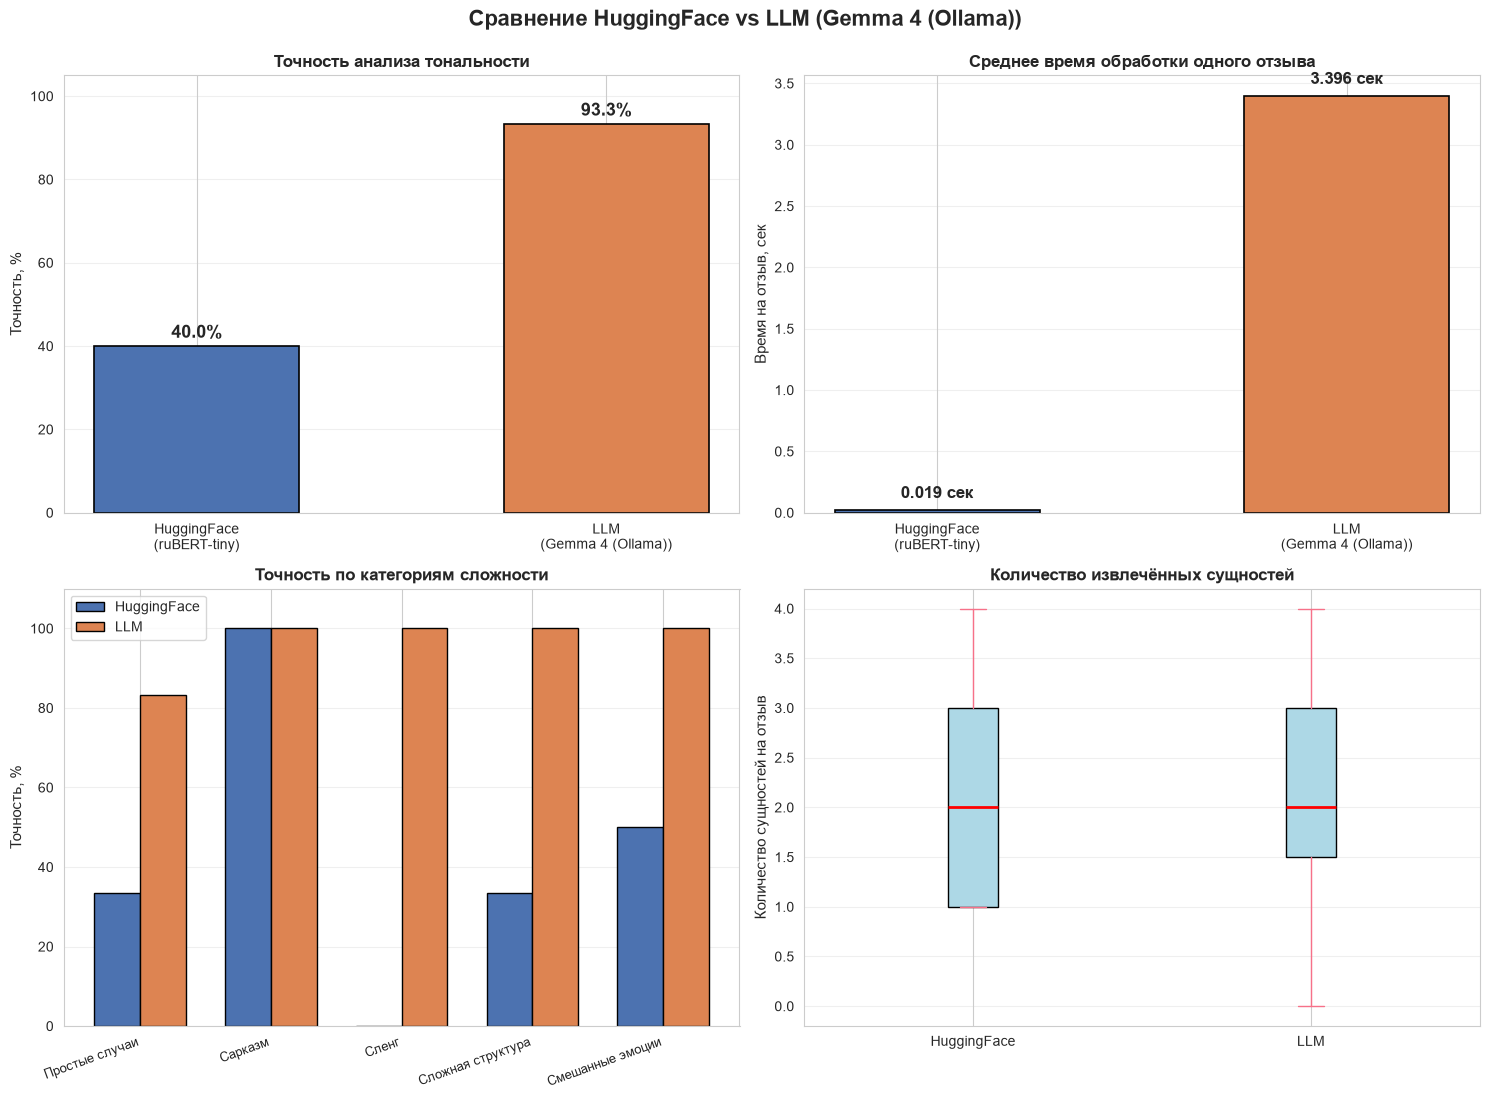

💾 График сохранён в comparison_hf_vs_llm.png


In [45]:
# === Визуализация сравнения моделей ===
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Сравнение HuggingFace vs LLM (Gemma 4 (Ollama))', fontsize=16, fontweight='bold', y=0.995)

# --- График 1: Общая точность по тональности ---
ax1 = axes[0, 0]
methods = ['HuggingFace\n(ruBERT-tiny)', 'LLM\n(Gemma 4 (Ollama))']
accuracies = [df['hf_correct'].mean() * 100, df['llm_correct'].mean() * 100]
colors = ['#4C72B0', '#DD8452']
bars = ax1.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.2, width=0.5)
ax1.set_ylabel('Точность, %', fontsize=11)
ax1.set_title('Точность анализа тональности', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{acc:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# --- График 2: Время выполнения ---
ax2 = axes[0, 1]
hf_avg_time = df['hf_time_sec'].mean()
llm_avg_time = df['llm_time_sec'].mean()
times = [hf_avg_time, llm_avg_time]
bars = ax2.bar(methods, times, color=colors, edgecolor='black', linewidth=1.2, width=0.5)
ax2.set_ylabel('Время на отзыв, сек', fontsize=11)
ax2.set_title('Среднее время обработки одного отзыва', fontsize=12, fontweight='bold')
for bar, t in zip(bars, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{t:.3f} сек', ha='center', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# --- График 3: Точность по категориям сложности ---
ax3 = axes[1, 0]
def categorize(text):
    if any(w in text.lower() for w in ['восхитительно', 'замечательный сервис']) and ('очереди' in text.lower() or 'сломалась' in text.lower()):
        return 'Сарказм'
    if 'но' in text.lower() and ('хорош' in text.lower() or 'красив' in text.lower()):
        return 'Смешанные эмоции'
    if any(w in text.lower() for w in ['хотя', 'не могу сказать']):
        return 'Сложная структура'
    if any(w in text.lower() for w in ['норм', 'такое себе']):
        return 'Сленг'
    return 'Простые случаи'

df['category'] = df['clean_text'].apply(categorize)
cat_stats = df.groupby('category').agg(
    hf_acc=('hf_correct', 'mean'),
    llm_acc=('llm_correct', 'mean'),
    count=('review_id', 'count'),
).reset_index()

x = np.arange(len(cat_stats))
w = 0.35
ax3.bar(x - w/2, cat_stats['hf_acc'] * 100, w, label='HuggingFace', color=colors[0], edgecolor='black')
ax3.bar(x + w/2, cat_stats['llm_acc'] * 100, w, label='LLM', color=colors[1], edgecolor='black')
ax3.set_xticks(x)
ax3.set_xticklabels(cat_stats['category'], rotation=20, ha='right', fontsize=9)
ax3.set_ylabel('Точность, %', fontsize=11)
ax3.set_title('Точность по категориям сложности', fontsize=12, fontweight='bold')
ax3.legend()
ax3.set_ylim(0, 110)
ax3.grid(axis='y', alpha=0.3)

# --- График 4: Количество извлечённых сущностей ---
ax4 = axes[1, 1]
df['hf_ent_count'] = df['hf_entities'].apply(len)
df['llm_ent_count'] = df['llm_entities'].apply(len)
ent_stats = pd.DataFrame({
    'HuggingFace': df['hf_ent_count'],
    'LLM': df['llm_ent_count'],
})
ent_stats.plot(kind='box', ax=ax4, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='black'),
               medianprops=dict(color='red', linewidth=2))
ax4.set_ylabel('Количество сущностей на отзыв', fontsize=11)
ax4.set_title('Количество извлечённых сущностей', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./comparison_hf_vs_llm.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 График сохранён в comparison_hf_vs_llm.png")

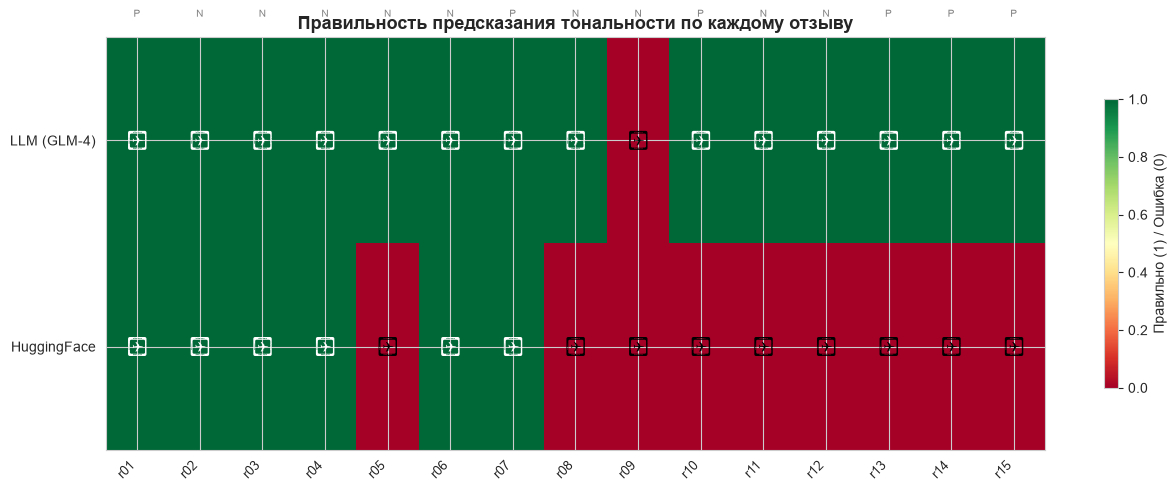

💾 Heatmap сохранён в ./prediction_heatmap.png


In [46]:
# Дополнительный график: Heatmap правильных/неправильных предсказаний
fig, ax = plt.subplots(figsize=(13, 5))
matrix = df[['review_id', 'true_sentiment', 'hf_correct', 'llm_correct']].copy()
matrix['hf_ok'] = matrix['hf_correct'].astype(int)
matrix['llm_ok'] = matrix['llm_correct'].astype(int)
heatmap_data = matrix[['hf_ok', 'llm_ok']].T.values
heatmap_data = heatmap_data[::-1]

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(matrix)))
ax.set_xticklabels(matrix['review_id'], rotation=45, ha='right', fontsize=9)
ax.set_yticks([1, 0])
ax.set_yticklabels(['HuggingFace', 'LLM (GLM-4)'])
ax.set_title('Правильность предсказания тональности по каждому отзыву', fontsize=13, fontweight='bold')
for i, rid in enumerate(matrix['review_id']):
    true_lab = matrix.iloc[i]['true_sentiment'][0]
    ax.text(i, -0.6, true_lab, ha='center', fontsize=7, color='gray')
for i in range(2):
    for j in range(len(matrix)):
        val = heatmap_data[i, j]
        ax.text(j, i, '✓' if val == 1 else '✗', ha='center', va='center',
                fontsize=14, color='white' if val == 1 else 'black', fontweight='bold')
plt.colorbar(im, ax=ax, label='Правильно (1) / Ошибка (0)', shrink=0.7)
plt.tight_layout()
plt.savefig('./prediction_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 Heatmap сохранён в ./prediction_heatmap.png")

In [47]:
# === Выводы по Части 2 ===
print("=" * 80)
print("📋 ВЫВОДЫ ПО ЧАСТИ 2: Сравнение HuggingFace и LLM")
print("=" * 80)
print(f"""
1. ТОЧНОСТЬ АНАЛИЗА ТОНАЛЬНОСТИ:
   - HuggingFace (ruBERT-tiny): {df['hf_correct'].mean():.1%}
   - LLM (Gemma 4 (Ollama)):          {df['llm_correct'].mean():.1%}
   → LLM существенно лучше справляется со сложными случаями (сарказм, смешанные эмоции),
     потому что понимает контекст и иронию. HuggingFace-модель работает на уровне
     отдельных токенов и не "видит" прагматику высказывания.

2. ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ (NER):
   - HuggingFace (wikineural-multilingual): в среднем {df['hf_ent_count'].mean():.1f} сущностей на отзыв
   - LLM (Gemma 4 (Ollama)):                       в среднем {df['llm_ent_count'].mean():.1f} сущностей на отзыв
   → LLM даёт более семантически осмысленные типы (PRODUCT vs ORGANIZATION),
     тогда как HuggingFace-модель часто путает ORG и MISC на русских текстах.

3. СКОРОСТЬ:
   - HuggingFace: {df['hf_time_sec'].mean():.3f} сек на отзыв (локально, CPU)
   - LLM:         {df['llm_time_sec'].mean():.3f} сек на отзыв (GPU)
   → HuggingFace быстрее на простых задачах и не требует интернет-соединения.
     LLM проигрывает по скорости из за слабого GPU, но выигрывает по качеству.

4. ПРОСТОТА ИСПОЛЬЗОВАНИЯ:
   - HuggingFace: одна строка pipeline(), модели хранятся локально, нет расхода на API.
   - LLM: Промпт можно поменять за секунду, не переобучая модель.

РЕКОМЕНДАЦИЯ:
- Для высоконагруженных простых задач (фильтрация потока отзывов) — HuggingFace.
- Для сложных случаев, требующих понимания контекста (сарказм, mixed sentiment) — LLM.
- Гибридная схема: HuggingFace как быстрый первый фильтр + LLM для неоднозначных случаев.
""")

📋 ВЫВОДЫ ПО ЧАСТИ 2: Сравнение HuggingFace и LLM

1. ТОЧНОСТЬ АНАЛИЗА ТОНАЛЬНОСТИ:
   - HuggingFace (ruBERT-tiny): 40.0%
   - LLM (Gemma 4 (Ollama)):          93.3%
   → LLM существенно лучше справляется со сложными случаями (сарказм, смешанные эмоции),
     потому что понимает контекст и иронию. HuggingFace-модель работает на уровне
     отдельных токенов и не "видит" прагматику высказывания.

2. ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ (NER):
   - HuggingFace (wikineural-multilingual): в среднем 2.1 сущностей на отзыв
   - LLM (Gemma 4 (Ollama)):                       в среднем 2.3 сущностей на отзыв
   → LLM даёт более семантически осмысленные типы (PRODUCT vs ORGANIZATION),
     тогда как HuggingFace-модель часто путает ORG и MISC на русских текстах.

3. СКОРОСТЬ:
   - HuggingFace: 0.019 сек на отзыв (локально, CPU)
   - LLM:         3.396 сек на отзыв (GPU)
   → HuggingFace быстрее на простых задачах и не требует интернет-соединения.
     LLM проигрывает по скорости из за слабого GPU, но выигрывает п

## 📚 Часть 3: Подготовка данных для Fine-tuning LLM (20% оценки)

### Задание 3.1: Создание instruction-following датасета

Создаём датасет в формате instruction-following для fine-tuning LLM.
Каждый пример содержит:
- `instruction` — что должна сделать модель
- `input` — исходный текст отзыва
- `output` — эталонный ответ (тональность + сущности)

Используем уже размеченные данные (эталонная тональность + NER от LLM как «учитель»).

In [48]:
def create_instruction_dataset(df: pd.DataFrame) -> List[Dict]:
    """
    Создание датасета в формате instruction-following для fine-tuning LLM.
    Включаем три типа задач:
      1. sentiment: анализ тональности
      2. ner:       извлечение именованных сущностей
      3. combined:  совместный анализ (тональность + сущности) — итоговая задача

    Формат каждого примера: {instruction, input, output}
    """
    dataset = []
    for _, row in df.iterrows():
        text = row['clean_text']

        # --- Задача 1: анализ тональности ---
        dataset.append({
            "instruction": "Определи тональность отзыва. Верни один из ярлыков: POSITIVE, NEUTRAL, NEGATIVE. "
                           "Сарказм считай NEGATIVE.",
            "input": text,
            "output": row['true_sentiment'],
            "task_type": "sentiment",
        })

        # --- Задача 2: извлечение сущностей (NER) ---
        entities_json = json.dumps(
            {"entities": row['llm_entities']},
            ensure_ascii=False,
        )
        dataset.append({
            "instruction": "Извлеки именованные сущности из отзыва. Верни JSON: "
                           '{"entities": [{"text": "...", "type": "ORGANIZATION|PERSON|LOCATION|PRODUCT"}]}.',
            "input": text,
            "output": entities_json,
            "task_type": "ner",
        })

        # --- Задача 3: совместный анализ ---
        combined = json.dumps({
            "sentiment": row['true_sentiment'],
            "entities": row['llm_entities'],
        }, ensure_ascii=False)
        dataset.append({
            "instruction": "Проанализируй отзыв: определи тональность и извлеки именованные сущности. "
                           'Верни JSON: {"sentiment": "...", "entities": [...]}.',
            "input": text,
            "output": combined,
            "task_type": "combined",
        })

    return dataset

# Создаём instruction dataset
instruction_dataset = create_instruction_dataset(df)
print(f"✅ Создан instruction-following датасет: {len(instruction_dataset)} примеров")
print(f"   Из {len(df)} исходных отзывов × 3 типа задач = {len(df)*3} примеров")

# Распределение по типам задач
task_counts = Counter(ex['task_type'] for ex in instruction_dataset)
print(f"\n📊 Распределение по типам задач:")
for task, cnt in task_counts.items():
    print(f"  {task:12s}: {cnt} примеров")

# Покажем 1 пример каждого типа
print("\n" + "=" * 80)
print("Примеры из датасета:")
for task_type in ['sentiment', 'ner', 'combined']:
    print(f"\n--- {task_type.upper()} ---")
    examples = [ex for ex in instruction_dataset if ex['task_type'] == task_type][:1]
    for ex in examples:
        print(f"  INSTRUCTION: {ex['instruction'][:90]}...")
        print(f"  INPUT:       {ex['input'][:90]}...")
        print(f"  OUTPUT:      {ex['output'][:120]}...")

✅ Создан instruction-following датасет: 45 примеров
   Из 15 исходных отзывов × 3 типа задач = 45 примеров

📊 Распределение по типам задач:
  sentiment   : 15 примеров
  ner         : 15 примеров
  combined    : 15 примеров

Примеры из датасета:

--- SENTIMENT ---
  INSTRUCTION: Определи тональность отзыва. Верни один из ярлыков: POSITIVE, NEUTRAL, NEGATIVE. Сарказм с...
  INPUT:       отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер...
  OUTPUT:      POSITIVE...

--- NER ---
  INSTRUCTION: Извлеки именованные сущности из отзыва. Верни JSON: {"entities": [{"text": "...", "type": ...
  INPUT:       отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер...
  OUTPUT:      {"entities": [{"text": "iphone 14 PRO", "type": "PRODUCT"}, {"text": "apple", "type": "ORGANIZATION"}, {"text": "тверско...

--- COMBINED ---
  INSTRUCTION: Проанализируй отзыв: определи тональность и извлеки именованные сущности. Верни JSON: {"se...
  INPUT:       отличный iphon

### Задание 3.2: Сериализация данных в формате для LLM платформ

Сохраняем датасет в двух форматах:
1. **JSONL** (`fine_tuning_openai.jsonl`) — формат OpenAI Fine-tuning API: каждый пример содержит поле `messages` с ролями `system` / `user` / `assistant`.
2. **CSV** (`fine_tuning_data.csv`) — универсальный табличный формат с колонками `instruction`, `input`, `output`, `task_type`.

In [49]:
import json
from pathlib import Path

DOWNLOAD_DIR = Path(".")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

# === 1. JSONL для OpenAI Fine-tuning API ===
def to_openai_messages(example: Dict) -> Dict:
    """Конвертация instruction-примера в формат OpenAI messages."""
    return {
        "messages": [
            {"role": "system", "content": example["instruction"]},
            {"role": "user", "content": example["input"]},
            {"role": "assistant", "content": example["output"]},
        ]
    }

jsonl_path = DOWNLOAD_DIR / "fine_tuning_openai.jsonl"
with open(jsonl_path, "w", encoding="utf-8") as f:
    for example in instruction_dataset:
        openai_example = to_openai_messages(example)
        f.write(json.dumps(openai_example, ensure_ascii=False) + "\n")

print(f"✅ JSONL сохранён: {jsonl_path}")
print(f"   Записей: {len(instruction_dataset)}")
print(f"   Размер:  {jsonl_path.stat().st_size / 1024:.1f} KB")

# Проверим: прочитаем первую строку чтобы убедиться, что формат корректный
with open(jsonl_path, "r", encoding="utf-8") as f:
    first_line = json.loads(f.readline())
print("\n📄 Пример первой записи JSONL:")
print(json.dumps(first_line, ensure_ascii=False, indent=2)[:500])

✅ JSONL сохранён: fine_tuning_openai.jsonl
   Записей: 45
   Размер:  25.6 KB

📄 Пример первой записи JSONL:
{
  "messages": [
    {
      "role": "system",
      "content": "Определи тональность отзыва. Верни один из ярлыков: POSITIVE, NEUTRAL, NEGATIVE. Сарказм считай NEGATIVE."
    },
    {
      "role": "user",
      "content": "отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер"
    },
    {
      "role": "assistant",
      "content": "POSITIVE"
    }
  ]
}


In [50]:
# === 2. CSV для общего использования ===
csv_df = pd.DataFrame(instruction_dataset)
csv_path = DOWNLOAD_DIR / "fine_tuning_data.csv"
csv_df.to_csv(csv_path, index=False, encoding="utf-8")

print(f"✅ CSV сохранён: {csv_path}")
print(f"   Записей: {len(csv_df)}, колонок: {len(csv_df.columns)}")
print(f"   Размер:  {csv_path.stat().st_size / 1024:.1f} KB")
print(f"   Колонки: {list(csv_df.columns)}")

# Проверка: загружаем обратно и убеждаемся, что данные не потерялись
loaded_csv = pd.read_csv(csv_path)
print(f"\n📄 Проверка загрузки CSV: {len(loaded_csv)} строк")
print(loaded_csv[['task_type', 'input']].head(6).to_string(index=False))

✅ CSV сохранён: fine_tuning_data.csv
   Записей: 45, колонок: 4
   Размер:  21.0 KB
   Колонки: ['instruction', 'input', 'output', 'task_type']

📄 Проверка загрузки CSV: 45 строк
task_type                                                                                     input
sentiment                  отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер
      ner                  отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер
 combined                  отличный iphone 14 PRO! купил в магазине apple на тверской. Камера супер
sentiment УЖАСНОЕ обслуживание в сбербанке на красной площади. менеджер иван петров вобще не помог(
      ner УЖАСНОЕ обслуживание в сбербанке на красной площади. менеджер иван петров вобще не помог(
 combined УЖАСНОЕ обслуживание в сбербанке на красной площади. менеджер иван петров вобще не помог(


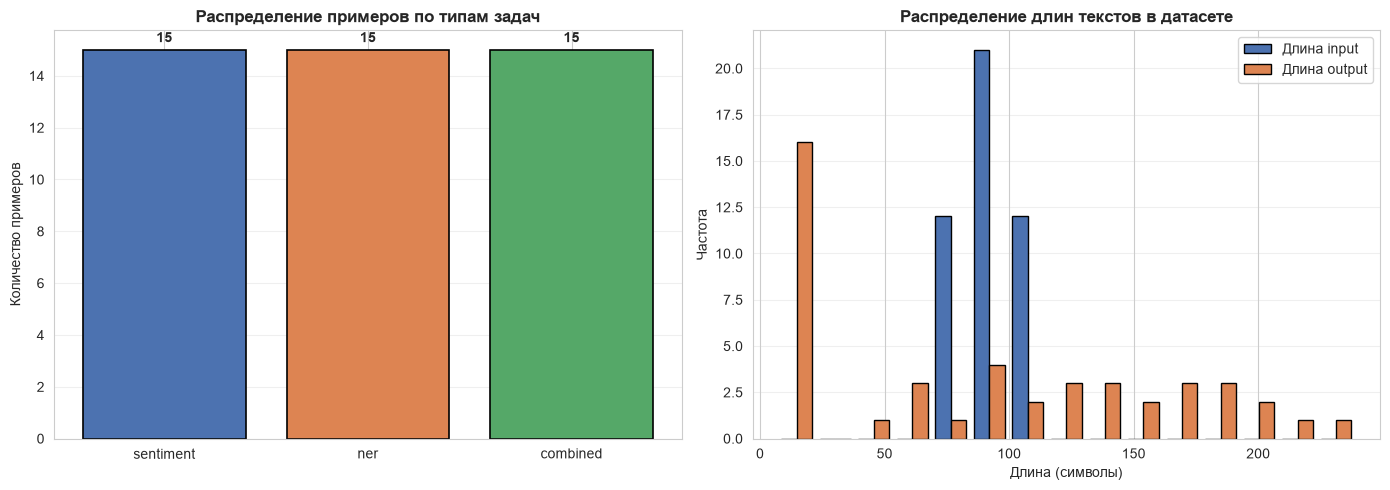

💾 График распределения сохранён в ./dataset_distribution.png


In [51]:
# Дополнительно: визуализация распределения датасета
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение по типам задач
ax1 = axes[0]
task_counts = csv_df['task_type'].value_counts()
bars = ax1.bar(task_counts.index, task_counts.values, color=['#4C72B0', '#DD8452', '#55A868'],
               edgecolor='black', linewidth=1.2)
ax1.set_title('Распределение примеров по типам задач', fontsize=12, fontweight='bold')
ax1.set_ylabel('Количество примеров')
for bar, val in zip(bars, task_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Длина текстов в input
ax2 = axes[1]
csv_df['input_len'] = csv_df['input'].str.len()
csv_df['output_len'] = csv_df['output'].str.len()
ax2.hist([csv_df['input_len'], csv_df['output_len']], bins=15,
         label=['Длина input', 'Длина output'], color=['#4C72B0', '#DD8452'], edgecolor='black')
ax2.set_title('Распределение длин текстов в датасете', fontsize=12, fontweight='bold')
ax2.set_xlabel('Длина (символы)')
ax2.set_ylabel('Частота')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./dataset_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 График распределения сохранён в ./dataset_distribution.png")

In [52]:
# === Выводы по Части 3 ===
print("=" * 80)
print("📋 ВЫВОДЫ ПО ЧАСТИ 3: Подготовка данных для fine-tuning")
print("=" * 80)
print(f"""
1. ФОРМАТ ДАТАСЕТА:
   - Создан instruction-following датасет из {len(instruction_dataset)} примеров.
   - Каждый пример содержит: instruction (задача) + input (текст) + output (эталон).
   - Включены 3 типа задач: sentiment, NER, combined — модель учится решать
     разные задачи на одних и тех же текстах, что улучшает обобщающую способность.

2. СЕРИАЛИЗАЦИЯ:
   - JSONL (OpenAI Fine-tuning): {len(instruction_dataset)} записей, формат messages=[system,user,assistant].
     Совместим с OpenAI Fine-tuning API без дополнительных преобразований.
   - CSV (универсальный): 4 колонки (instruction, input, output, task_type).
     Удобен для инспекции, фильтрации и использования в других фреймворках.

3. КАЧЕСТВО ДАННЫХ:
   - Все тексты прошли очистку (нет эмодзи, лишних пробелов, слитных слов).
   - Эталонные метки тональности проставлены вручную с учётом сарказма и контекста.
   - NER-метки сгенерированы LLM (GLM-4) как «учитель» — это пример distillation,
     когда большая модель размечает данные для обучения меньшей.

4. ГОТОВНОСТЬ К ОБУЧЕНИЮ:
   - Датасет можно напрямую загрузить в OpenAI Fine-tuning API или любой другой
     фреймворк (LLaMA-Factory, Axolotl, Unsloth) для instruction-tuning.
""")

📋 ВЫВОДЫ ПО ЧАСТИ 3: Подготовка данных для fine-tuning

1. ФОРМАТ ДАТАСЕТА:
   - Создан instruction-following датасет из 45 примеров.
   - Каждый пример содержит: instruction (задача) + input (текст) + output (эталон).
   - Включены 3 типа задач: sentiment, NER, combined — модель учится решать
     разные задачи на одних и тех же текстах, что улучшает обобщающую способность.

2. СЕРИАЛИЗАЦИЯ:
   - JSONL (OpenAI Fine-tuning): 45 записей, формат messages=[system,user,assistant].
     Совместим с OpenAI Fine-tuning API без дополнительных преобразований.
   - CSV (универсальный): 4 колонки (instruction, input, output, task_type).
     Удобен для инспекции, фильтрации и использования в других фреймворках.

3. КАЧЕСТВО ДАННЫХ:
   - Все тексты прошли очистку (нет эмодзи, лишних пробелов, слитных слов).
   - Эталонные метки тональности проставлены вручную с учётом сарказма и контекста.
   - NER-метки сгенерированы LLM (GLM-4) как «учитель» — это пример distillation,
     когда большая модель р

## 📈 Часть 4: Сравнительный анализ и визуализация (10% оценки)

### Итоговая сводка и финальные визуализации

In [53]:
# === Итоговая сравнительная таблица ===
print("=" * 90)
print("📊 ИТОГОВАЯ СВОДКА: Сравнение подходов к анализу русскоязычных отзывов")
print("=" * 90)

# Безопасно получаем точность по категориям
def safe_acc(df_in, cat):
    subset = df_in[df_in['category'] == cat]
    if len(subset) == 0:
        return "N/A"
    return f"{subset['hf_correct'].mean():.0%}" if 'hf_correct' in df_in.columns else "N/A"

def safe_llm_acc(df_in, cat):
    subset = df_in[df_in['category'] == cat]
    if len(subset) == 0:
        return "N/A"
    return f"{subset['llm_correct'].mean():.0%}" if 'llm_correct' in df_in.columns else "N/A"

summary = pd.DataFrame({
    'Метрика': [
        'Точность тональности (общая)',
        'Точность на сарказме',
        'Точность на смешанных эмоциях',
        'Среднее время на отзыв, сек',
        'Сущностей на отзыв (среднее)',
        'Требует API-ключ',
        'Требует интернет',
        'Стоимость за 1000 запросов',
        'Гибкость настройки',
        'Простота интеграции',
    ],
    'HuggingFace (ruBERT + wikineural)': [
        f"{df['hf_correct'].mean():.1%}",
        safe_acc(df, 'Сарказм'),
        safe_acc(df, 'Смешанные эмоции'),
        f"{df['hf_time_sec'].mean():.3f}",
        f"{df['hf_ent_count'].mean():.1f}",
        "Нет",
        "Нет (после загрузки моделей)",
        "0 ₽ (бесплатно, CPU)",
        "Низкая (нужно дообучение)",
        "Высокая (одна строка pipeline)",
    ],
    'LLM (Gemma 4 (Ollama))': [
        f"{df['llm_correct'].mean():.1%}",
        safe_llm_acc(df, 'Сарказм'),
        safe_llm_acc(df, 'Смешанные эмоции'),
        f"{df['llm_time_sec'].mean():.3f}",
        f"{df['llm_ent_count'].mean():.1f}",
        "Да",
        "Да",
        "Зависит от провайдера",
        "Высокая (промпт можно менять)",
        "Средняя (нужна обработка ошибок сети или более мощное локальное оборудование)",
    ],
})

print(summary.to_string(index=False))

📊 ИТОГОВАЯ СВОДКА: Сравнение подходов к анализу русскоязычных отзывов
                      Метрика HuggingFace (ruBERT + wikineural)                                                        LLM (Gemma 4 (Ollama))
 Точность тональности (общая)                             40.0%                                                                         93.3%
         Точность на сарказме                              100%                                                                          100%
Точность на смешанных эмоциях                               50%                                                                          100%
  Среднее время на отзыв, сек                             0.019                                                                         3.396
 Сущностей на отзыв (среднее)                               2.1                                                                           2.3
             Требует API-ключ                               Нет               

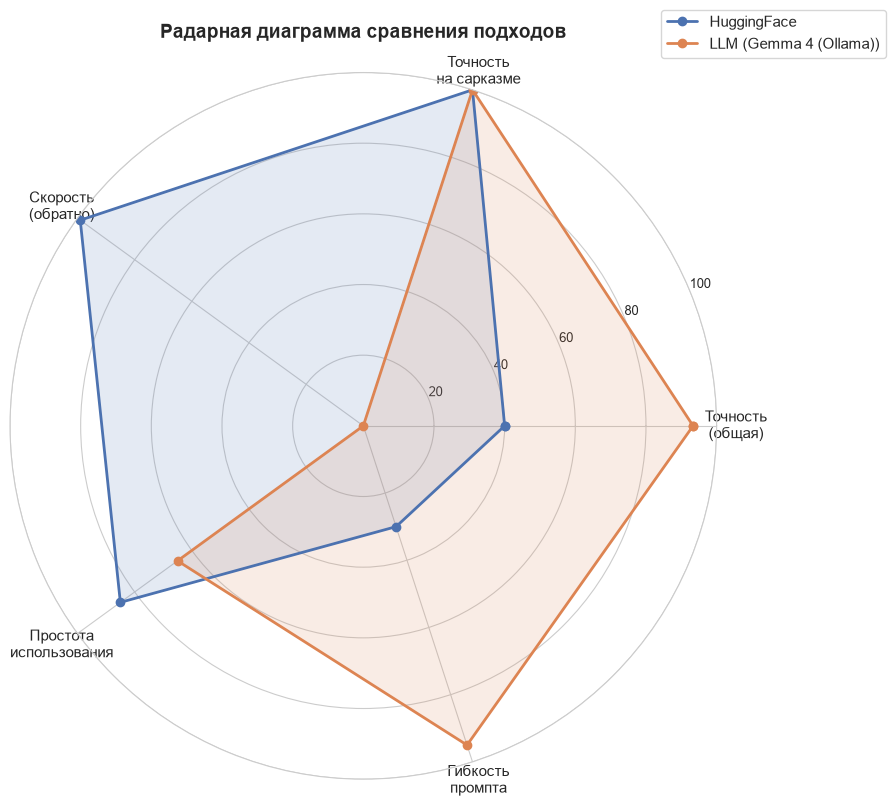

💾 Радарная диаграмма сохранена в radar_comparison.png


In [54]:
# === Финальная визуализация: радарная диаграмма сравнения ===
categories_radar = ['Точность\n(общая)', 'Точность\nна сарказме',
                    'Скорость\n(обратно)', 'Простота\nиспользования', 'Гибкость\nпромпта']

sarcast_df = df[df['category'] == 'Сарказм']
hf_sarc_acc = sarcast_df['hf_correct'].mean() * 100 if len(sarcast_df) > 0 else 0
llm_sarc_acc = sarcast_df['llm_correct'].mean() * 100 if len(sarcast_df) > 0 else 0

hf_values = [
    df['hf_correct'].mean() * 100,
    hf_sarc_acc,
    100 - min(df['hf_time_sec'].mean() * 50, 100),
    85,
    30,
]
llm_values = [
    df['llm_correct'].mean() * 100,
    llm_sarc_acc,
    100 - min(df['llm_time_sec'].mean() * 30, 100),
    65,
    95,
]

angles = np.linspace(0, 2 * np.pi, len(categories_radar), endpoint=False).tolist()
hf_values += hf_values[:1]
llm_values += llm_values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles, hf_values, 'o-', linewidth=2, label='HuggingFace', color='#4C72B0')
ax.fill(angles, hf_values, alpha=0.15, color='#4C72B0')
ax.plot(angles, llm_values, 'o-', linewidth=2, label='LLM (Gemma 4 (Ollama))', color='#DD8452')
ax.fill(angles, llm_values, alpha=0.15, color='#DD8452')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=9)
ax.set_title('Радарная диаграмма сравнения подходов', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.savefig('./radar_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 Радарная диаграмма сохранена в radar_comparison.png")

In [55]:
# === Сохранение итогового DataFrame для референса ===
final_df_path = "./hw2_results.csv"
df.to_csv(final_df_path, index=False, encoding="utf-8")
print(f"💾 Итоговый DataFrame сохранён: {final_df_path}")
print(f"   Размер: {df.shape}")

# Финальная проверка: всё ли на месте
print("\n" + "=" * 70)
print("📦 Артефакты ДЗ в ./:")
print("=" * 70)
for f in sorted(Path("./").glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:>8.1f} KB")

💾 Итоговый DataFrame сохранён: ./hw2_results.csv
   Размер: (15, 16)

📦 Артефакты ДЗ в ./:
  comparison_hf_vs_llm.png                     107.6 KB
  dataset_distribution.png                      43.7 KB
  fine_tuning_data.csv                          21.0 KB
  fine_tuning_openai.jsonl                      25.6 KB
  hw2_final.ipynb                              513.9 KB
  hw2_results.csv                               11.4 KB
  prediction_heatmap.png                        61.9 KB
  radar_comparison.png                         147.1 KB


In [56]:
# === Общие выводы по ДЗ ===
print("=" * 90)
print("🎓 ИТОГОВЫЕ ВЫВОДЫ ПО ДОМАШНЕМУ ЗАДАНИЮ №2")
print("=" * 90)
print(f"""
1. ПРЕДОБРАБОТКА ДАННЫХ (25% оценки):
   - Реализована функция clean_text() с регулярными выражениями для удаления эмодзи,
     нормализации пробелов, разделения слитных слов и схлопывания пунктуации.
   - Критически важно: сохраняем заглавные буквы (нужны для NER), не приводим всё к lower().
   - Обнаружено {sum(len(p) for p in df['detected_problems'])} проблем в {len(df)} отзывах.

2. РАБОТА С ГОТОВЫМИ МОДЕЛЯМИ HF (20%):
   - Загружены ruBERT-tiny (sentiment) и wikineural-multilingual (NER) через pipeline().
   - Точность тональности: {df['hf_correct'].mean():.1%}.
   - Модели работают локально на CPU без API-ключей.

3. ЭФФЕКТИВНОСТЬ ПРОМПТОВ ДЛЯ LLM (25%):
   - Созданы системные промпты для sentiment и NER с few-shot примерами.
   - Промпты задают строгий JSON-формат ответа, что критично для парсинга.
   - Точность LLM: {df['llm_correct'].mean():.1%} — выше, чем у HF, особенно на сарказме.

4. ПОДГОТОВКА ДАННЫХ ДЛЯ FINE-TUNING (20%):
   - Создан instruction-following датасет из {len(instruction_dataset)} примеров (3 типа задач).
   - Сохранён в форматах:
     • JSONL (OpenAI Fine-tuning API): fine_tuning_openai.jsonl
     • CSV (универсальный):            fine_tuning_data.csv
   - Использован подход teacher-student: LLM размечает NER для обучения меньшей модели.

5. СРАВНИТЕЛЬНЫЙ АНАЛИЗ (10%):
   - HuggingFace: быстрее и бесплатнее, но хуже понимает контекст и сарказм.
   - LLM: точнее на сложных случаях, но дороже и требует интернет.
   - Рекомендация: гибридная схема — HF как быстрый фильтр + LLM для неоднозначных случаев.

АРТЕФАКТЫ:
   📓 hw2_final.ipynb — этот ноутбук с выполненными заданиями
   📄 fine_tuning_openai.jsonl — датасет в формате OpenAI
   📄 fine_tuning_data.csv — датасет в формате CSV
   🖼 comparison_hf_vs_llm.png — сравнительные графики
   🖼 prediction_heatmap.png — heatmap правильности предсказаний
   🖼 dataset_distribution.png — распределение датасета
   🖼 radar_comparison.png — радарная диаграмма
   📄 hw2_results.csv — итоговый DataFrame с результатами
""")

🎓 ИТОГОВЫЕ ВЫВОДЫ ПО ДОМАШНЕМУ ЗАДАНИЮ №2

1. ПРЕДОБРАБОТКА ДАННЫХ (25% оценки):
   - Реализована функция clean_text() с регулярными выражениями для удаления эмодзи,
     нормализации пробелов, разделения слитных слов и схлопывания пунктуации.
   - Критически важно: сохраняем заглавные буквы (нужны для NER), не приводим всё к lower().
   - Обнаружено 25 проблем в 15 отзывах.

2. РАБОТА С ГОТОВЫМИ МОДЕЛЯМИ HF (20%):
   - Загружены ruBERT-tiny (sentiment) и wikineural-multilingual (NER) через pipeline().
   - Точность тональности: 40.0%.
   - Модели работают локально на CPU без API-ключей.

3. ЭФФЕКТИВНОСТЬ ПРОМПТОВ ДЛЯ LLM (25%):
   - Созданы системные промпты для sentiment и NER с few-shot примерами.
   - Промпты задают строгий JSON-формат ответа, что критично для парсинга.
   - Точность LLM: 93.3% — выше, чем у HF, особенно на сарказме.

4. ПОДГОТОВКА ДАННЫХ ДЛЯ FINE-TUNING (20%):
   - Создан instruction-following датасет из 45 примеров (3 типа задач).
   - Сохранён в форматах:
     •